# Chest X-ray Pneumonia Classification Using Transfer Learning and Spark

**Submission notebook**

This notebook implements a paper-style replication and improvement of pediatric chest X-ray pneumonia classification. It builds two binary classifiers:

- **Task 1:** NORMAL vs PNEUMONIA using InceptionV3 transfer learning.
- **Task 2:** BACTERIAL vs VIRAL pneumonia using DenseNet121 transfer learning and fine-tuning.

The workflow uses Apache Spark to create the image manifest, engineer labels, summarize class distributions, and prepare train, validation, and test splits. TensorFlow/Keras is used for model training, evaluation, ROC analysis, and occlusion-based visual explanation.


## Final Results Summary

| Task | Final model | Test split | Base paper accuracy | Notebook accuracy | Result |
|---|---|---:|---:|---:|---|
| NORMAL vs PNEUMONIA | InceptionV3 frozen feature extractor | 919 images | 92.8% | 95.76% | Crossed base paper |
| BACTERIAL vs VIRAL | DenseNet121 with fine-tuning | 390 original test images | 90.7% | 92.31% | Crossed base paper |

The Task 2 evaluation uses the original paper-style TEST folder distribution: 242 bacterial and 148 viral pneumonia images. This makes the Task 2 comparison more directly aligned with the base paper.


## Notebook Flow

1. Mount Google Drive and install required libraries.
2. Confirm that Colab is using a GPU.
3. Import libraries and define configuration values.
4. Build a Spark manifest from the chest X-ray dataset.
5. Create labels and train/validation/test splits.
6. Display sample NORMAL, BACTERIAL pneumonia, and VIRAL pneumonia images.
7. Train and evaluate Task 1 with InceptionV3.
8. Train and evaluate Task 2 with DenseNet121 on the original paper-style split.
9. Generate occlusion maps to show image regions that influence predictions.


## 1. Environment Setup

This cell mounts Google Drive and installs the Python packages required for TensorFlow training, Spark-based preprocessing, data analysis, and plotting.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q tensorflow scikit-learn pandas seaborn matplotlib pyspark


Mounted at /content/drive


## 2. GPU Verification

The models train much faster on a GPU. The output should list one GPU device before training starts.


In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

if tf.config.list_physical_devices('GPU'):
    print("GPU is enabled.")
else:
    print("Still running on CPU. Change runtime type to GPU.")


TensorFlow version: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU is enabled.


## 3. Imports

These imports support dataset handling, Spark processing, transfer learning, model evaluation, and visualization.


In [7]:
import math
import os
import random
import re
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import types as T
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import Model
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import img_to_array, load_img

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_colwidth', 200)


## 4. Configuration

This section defines reproducibility settings, image size, batch size, augmentation settings, dataset paths, and output model paths.


In [8]:
# -----------------------------
# Configuration
# -----------------------------
SEED = 42
IMAGE_SIZE = (299, 299)
BATCH_SIZE = 32
EPOCHS = 30
LEARNING_RATE = 1e-3
VAL_SIZE = 0.15
TEST_SIZE = 0.15
MIN_DELTA = 1e-4
OVERSAMPLE_MINORITY = True
USE_TEST_TIME_AUGMENTATION = True
TTA_STEPS = 3
AUGMENTATION_SETTINGS = {
    'rotation_range': 12,
    'width_shift_range': 0.08,
    'height_shift_range': 0.08,
    'zoom_range': 0.15,
    'shear_range': 0.05,
    'brightness_range': [0.85, 1.15],
    'horizontal_flip': True,
    'fill_mode': 'nearest',
}

DRIVE_DATASET_ROOT = Path('/content/drive/MyDrive/Big Data/ChestXRay2017')
DRIVE_DATASET_DIR = DRIVE_DATASET_ROOT / 'chest_xray'
LOCAL_DATASET_ROOT = Path('/content/ChestXRay2017')
LOCAL_DATASET_DIR = LOCAL_DATASET_ROOT / 'chest_xray'
DATASET_DIR = LOCAL_DATASET_DIR
OUTPUT_DIR = DRIVE_DATASET_ROOT / 'paper_style_outputs_spark'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TASK1_MODEL_PATH = OUTPUT_DIR / 'inceptionv3_pneumonia_vs_normal.keras'
TASK2_MODEL_PATH = OUTPUT_DIR / 'inceptionv3_bacterial_vs_viral.keras'

print('Drive dataset dir:', DRIVE_DATASET_DIR)
print('Local dataset dir:', LOCAL_DATASET_DIR)
print('Output dir :', OUTPUT_DIR)


Drive dataset dir: /content/drive/MyDrive/Big Data/ChestXRay2017/chest_xray
Local dataset dir: /content/ChestXRay2017/chest_xray
Output dir : /content/drive/MyDrive/Big Data/ChestXRay2017/paper_style_outputs_spark


## 5. Spark Manifest and Dataset Split Helpers

These helper functions parse filenames, identify pneumonia subtype labels, create the Spark manifest, summarize the dataset, and generate train/validation/test splits.


In [9]:
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


def copy_dataset_to_local():
    if LOCAL_DATASET_DIR.exists():
        print("Local dataset already exists. Skipping copy.")
    else:
        print("Copying dataset from Google Drive to Colab local disk...")
        shutil.copytree(DRIVE_DATASET_DIR, LOCAL_DATASET_DIR)
        print("Copy complete.")

    print("Training and Spark manifest will use:", LOCAL_DATASET_DIR)
    return LOCAL_DATASET_DIR


def create_spark_session():
    return (
        SparkSession.builder.appName("ChestXRayPaperStyleSpark")
        .master("local[*]")
        .getOrCreate()
    )


def parse_patient_id(filename: str) -> str:
    stem = Path(filename).stem
    patterns = [
        r"^(person\d+)",
        r"^(NORMAL\d+-IM-\d+)",
        r"^(NORMAL\d+-\d+)",
        r"^(IM-\d+-\d+)",
    ]
    for pattern in patterns:
        match = re.match(pattern, stem, flags=re.IGNORECASE)
        if match:
            return match.group(1).lower()
    if "_" in stem:
        return stem.split("_")[0].lower()
    return stem.lower()


def pneumonia_subtype_from_name(filename: str):
    lower = Path(filename).name.lower()
    if "bacteria" in lower:
        return "BACTERIAL"
    if "virus" in lower:
        return "VIRAL"
    return None


def build_manifest_rows(dataset_dir: Path):
    rows = []
    valid_suffixes = {".jpg", ".jpeg", ".png"}

    for path in dataset_dir.rglob("*"):
        if not path.is_file() or path.suffix.lower() not in valid_suffixes:
            continue

        split_folder = path.parent.parent.name.upper() if path.parent.parent != path.parent else "UNKNOWN"
        folder_label = path.parent.name.upper()
        subtype = pneumonia_subtype_from_name(path.name)
        patient_id = parse_patient_id(path.name)

        rows.append(
            (
                str(path),
                path.name,
                split_folder,
                folder_label,
                patient_id,
                subtype,
                path.suffix.lower(),
                path.stat().st_size,
            )
        )
    return rows


def create_manifest_df(spark, dataset_dir: Path):
    schema = T.StructType(
        [
            T.StructField("filepath", T.StringType(), False),
            T.StructField("filename", T.StringType(), False),
            T.StructField("split_folder", T.StringType(), True),
            T.StructField("folder_label", T.StringType(), True),
            T.StructField("patient_id", T.StringType(), True),
            T.StructField("pneumonia_subtype", T.StringType(), True),
            T.StructField("extension", T.StringType(), True),
            T.StructField("bytes", T.LongType(), True),
        ]
    )
    rows = build_manifest_rows(dataset_dir)
    if not rows:
        raise FileNotFoundError(f"No images found under {dataset_dir}")
    return spark.createDataFrame(rows, schema=schema)


def show_manifest_summary(manifest_df):
    print("Total images:", manifest_df.count())
    manifest_df.groupBy("split_folder").count().orderBy("split_folder").show()
    manifest_df.groupBy("split_folder", "folder_label").count().orderBy("split_folder", "folder_label").show()
    manifest_df.groupBy("folder_label").agg(
        F.count("*").alias("images"),
        F.countDistinct("patient_id").alias("patients"),
        F.round(F.avg("bytes") / 1024, 2).alias("avg_kb"),
    ).orderBy("folder_label").show()


def build_task_df(manifest_df, task_name: str):
    if task_name == "pneumonia_vs_normal":
        return (
            manifest_df.filter(F.col("folder_label").isin("NORMAL", "PNEUMONIA"))
            .withColumn("label", F.col("folder_label"))
            .select("filepath", "filename", "patient_id", "label")
        )

    if task_name == "bacterial_vs_viral":
        return (
            manifest_df.filter((F.col("folder_label") == "PNEUMONIA") & F.col("pneumonia_subtype").isNotNull())
            .withColumn("label", F.col("pneumonia_subtype"))
            .select("filepath", "filename", "patient_id", "label")
        )

    raise ValueError(f"Unknown task: {task_name}")


def summarize_task_df(task_df, title):
    print(f"\n{title}")
    print("Images  :", task_df.count())
    print("Patients:", task_df.select("patient_id").distinct().count())
    task_df.groupBy("label").count().orderBy("label").show()


def patient_level_split_spark(task_df, val_size=VAL_SIZE, test_size=TEST_SIZE, seed=SEED):
    pdf = task_df.toPandas()
    patient_pdf = pdf.groupby("patient_id")["label"].agg(lambda x: x.mode().iat[0]).reset_index()
    class_counts = patient_pdf["label"].value_counts()
    stratify_labels = patient_pdf["label"] if class_counts.min() >= 2 else None

    train_patients, temp_patients = train_test_split(
        patient_pdf,
        test_size=val_size + test_size,
        random_state=seed,
        stratify=stratify_labels,
    )

    temp_ratio = test_size / (val_size + test_size)
    temp_stratify = temp_patients["label"] if temp_patients["label"].value_counts().min() >= 2 else None
    val_patients, test_patients = train_test_split(
        temp_patients,
        test_size=temp_ratio,
        random_state=seed,
        stratify=temp_stratify,
    )

    train_ids = set(train_patients["patient_id"])
    val_ids = set(val_patients["patient_id"])
    test_ids = set(test_patients["patient_id"])

    train_pdf = pdf[pdf["patient_id"].isin(train_ids)].copy()
    val_pdf = pdf[pdf["patient_id"].isin(val_ids)].copy()
    test_pdf = pdf[pdf["patient_id"].isin(test_ids)].copy()

    return train_pdf.reset_index(drop=True), val_pdf.reset_index(drop=True), test_pdf.reset_index(drop=True)


def image_level_fallback_split_spark(task_df, val_size=VAL_SIZE, test_size=TEST_SIZE, seed=SEED):
    pdf = task_df.toPandas()
    train_pdf, temp_pdf = train_test_split(
        pdf,
        test_size=val_size + test_size,
        random_state=seed,
        stratify=pdf["label"],
    )
    temp_ratio = test_size / (val_size + test_size)
    val_pdf, test_pdf = train_test_split(
        temp_pdf,
        test_size=temp_ratio,
        random_state=seed,
        stratify=temp_pdf["label"],
    )
    return train_pdf.reset_index(drop=True), val_pdf.reset_index(drop=True), test_pdf.reset_index(drop=True)


def make_splits(task_df, task_name):
    pdf = task_df.select("patient_id").toPandas()
    unique_patients = pdf["patient_id"].nunique()
    same_as_images = unique_patients == len(pdf)

    if unique_patients >= 20 and not same_as_images:
        print(f"Using patient-level split for {task_name}.")
        return patient_level_split_spark(task_df)

    print(f"Patient IDs not reliable enough for {task_name}; using image-level fallback split.")
    return image_level_fallback_split_spark(task_df)


def summarize_split(name, split_df):
    print(f"\n{name}")
    print("Images  :", len(split_df))
    print("Patients:", split_df["patient_id"].nunique())
    print(split_df["label"].value_counts())


## 6. Model, Training, and Evaluation Helpers

This section defines class balancing, image generators, the InceptionV3 Task 1 model, threshold selection, ROC/confusion-matrix evaluation, and the reusable training function.


In [10]:
def balance_training_dataframe(train_df):
    if not OVERSAMPLE_MINORITY:
        return train_df.copy()

    max_count = train_df['label'].value_counts().max()
    balanced_parts = []
    for label, group in train_df.groupby('label'):
        balanced_parts.append(
            group.sample(n=max_count, replace=len(group) < max_count, random_state=SEED)
        )

    balanced_df = pd.concat(balanced_parts, ignore_index=True)
    balanced_df = balanced_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
    print('Balanced training distribution:')
    print(balanced_df['label'].value_counts())
    return balanced_df


def make_generators(train_df, val_df, test_df):
    train_df = balance_training_dataframe(train_df)
    class_names = sorted(train_df['label'].unique().tolist())
    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        **AUGMENTATION_SETTINGS,
    )

    eval_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

    train_gen = train_datagen.flow_from_dataframe(
        dataframe=train_df,
        x_col='filepath',
        y_col='label',
        target_size=IMAGE_SIZE,
        classes=class_names,
        class_mode='binary',
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=SEED,
    )

    val_gen = eval_datagen.flow_from_dataframe(
        dataframe=val_df,
        x_col='filepath',
        y_col='label',
        target_size=IMAGE_SIZE,
        classes=class_names,
        class_mode='binary',
        batch_size=BATCH_SIZE,
        shuffle=False,
    )

    test_gen = eval_datagen.flow_from_dataframe(
        dataframe=test_df,
        x_col='filepath',
        y_col='label',
        target_size=IMAGE_SIZE,
        classes=class_names,
        class_mode='binary',
        batch_size=BATCH_SIZE,
        shuffle=False,
    )

    return train_gen, val_gen, test_gen


def compute_class_weights_from_generator(train_gen):
    labels = train_gen.classes
    classes = np.unique(labels)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=labels)
    return {int(c): float(w) for c, w in zip(classes, weights)}


def build_model():
    backbone = InceptionV3(
        weights='imagenet',
        include_top=False,
        input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3),
    )
    backbone.trainable = False

    x = backbone.output
    x = GlobalAveragePooling2D(name='gap')(x)
    x = Dropout(0.5, name='dropout')(x)
    out = Dense(1, activation='sigmoid', name='prediction')(x)

    model = Model(inputs=backbone.input, outputs=out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
        ],
    )
    return model


def plot_history(history, title):
    hist = history.history
    epochs = range(1, len(hist['loss']) + 1)

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, hist['loss'], label='Train')
    plt.plot(epochs, hist['val_loss'], label='Validation')
    plt.title(f'{title} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, hist['accuracy'], label='Train')
    plt.plot(epochs, hist['val_accuracy'], label='Validation')
    plt.title(f'{title} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.show()


def pick_best_threshold(y_true, probs):
    thresholds = np.arange(0.10, 0.91, 0.01)
    best = {'threshold': 0.50, 'accuracy': -1, 'balanced_accuracy': -1}

    for threshold in thresholds:
        preds = (probs >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
        accuracy = (tp + tn) / (tp + tn + fp + fn)
        sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
        specificity = tn / (tn + fp) if (tn + fp) else 0.0
        balanced = (sensitivity + specificity) / 2.0

        if balanced > best['balanced_accuracy'] or (balanced == best['balanced_accuracy'] and accuracy > best['accuracy']):
            best = {'threshold': float(threshold), 'accuracy': float(accuracy), 'balanced_accuracy': float(balanced)}

    return best


def predict_with_tta(model, eval_df, class_names, steps=TTA_STEPS):
    tta_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        **AUGMENTATION_SETTINGS,
    )
    predictions = []

    for step in range(steps):
        tta_gen = tta_datagen.flow_from_dataframe(
            dataframe=eval_df,
            x_col='filepath',
            y_col='label',
            target_size=IMAGE_SIZE,
            classes=class_names,
            class_mode='binary',
            batch_size=BATCH_SIZE,
            shuffle=False,
            seed=SEED + step,
        )
        predictions.append(model.predict(tta_gen, verbose=0).ravel())

    return np.mean(predictions, axis=0)


def evaluate_model(model, generator, class_names, threshold=0.5, title='Evaluation', eval_df=None):
    if USE_TEST_TIME_AUGMENTATION and eval_df is not None:
        print(f'Using test-time augmentation with {TTA_STEPS} prediction passes.')
        probs = predict_with_tta(model, eval_df, class_names, steps=TTA_STEPS)
    else:
        probs = model.predict(generator, verbose=1).ravel()
    y_true = generator.classes
    preds = (probs >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    auc = roc_auc_score(y_true, probs)

    print(f'\n{title}')
    print(f'Threshold   : {threshold:.2f}')
    print(f'Accuracy    : {accuracy:.4f}')
    print(f'Sensitivity : {sensitivity:.4f}')
    print(f'Specificity : {specificity:.4f}')
    print(f'ROC-AUC     : {auc:.4f}')
    print('\nClassification report:\n')
    print(classification_report(y_true, preds, target_names=class_names, digits=4))

    cm = confusion_matrix(y_true, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{title} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    fpr, tpr, _ = roc_curve(y_true, probs)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
    plt.plot([0, 1], [0, 1], '--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{title} ROC Curve')
    plt.legend(loc='lower right')
    plt.show()

    return {
        'threshold': threshold,
        'accuracy': accuracy,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'auc': auc,
        'probs': probs,
        'y_true': y_true,
        'preds': preds,
    }


def train_task(task_name, train_df, val_df, test_df, model_path):
    train_gen, val_gen, test_gen = make_generators(train_df, val_df, test_df)
    class_names = list(train_gen.class_indices.keys())
    class_weights = compute_class_weights_from_generator(train_gen)

    print(f'\nTask: {task_name}')
    print('Class names  :', class_names)
    print('Class weights:', class_weights)

    model = build_model()
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=10, min_delta=MIN_DELTA, restore_best_weights=True, verbose=1),
        ModelCheckpoint(filepath=str(model_path), monitor='val_loss', save_best_only=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=4, min_lr=1e-6, verbose=1),
    ]

    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS,
        class_weight=class_weights,
        callbacks=callbacks,
        verbose=1,
    )

    plot_history(history, title=task_name)
    model = tf.keras.models.load_model(model_path)

    if USE_TEST_TIME_AUGMENTATION:
        val_probs = predict_with_tta(model, val_df, class_names, steps=TTA_STEPS)
    else:
        val_probs = model.predict(val_gen, verbose=0).ravel()
    best_threshold = pick_best_threshold(val_gen.classes, val_probs)
    print('\nBest validation threshold:', best_threshold)

    test_metrics = evaluate_model(
        model,
        test_gen,
        class_names=class_names,
        threshold=best_threshold['threshold'],
        title=task_name,
        eval_df=test_df,
    )

    return {
        'model': model,
        'history': history,
        'train_gen': train_gen,
        'val_gen': val_gen,
        'test_gen': test_gen,
        'class_names': class_names,
        'metrics': test_metrics,
        'best_threshold': best_threshold,
        'train_df': train_df,
        'val_df': val_df,
        'test_df': test_df,
    }


## 7. Dataset Preparation with Spark

The dataset is copied from Drive to local Colab storage, converted into a Spark manifest, summarized, and split into Task 1 and Task 2 datasets.


In [11]:
set_seed()
DATASET_DIR = copy_dataset_to_local()
spark = create_spark_session()
manifest_df = create_manifest_df(spark, DATASET_DIR).cache()
show_manifest_summary(manifest_df)

task1_spark_df = build_task_df(manifest_df, 'pneumonia_vs_normal').cache()
summarize_task_df(task1_spark_df, 'Task 1 Spark Summary: Pneumonia vs Normal')
task1_train_df, task1_val_df, task1_test_df = make_splits(task1_spark_df, 'pneumonia_vs_normal')
summarize_split('Task 1 Train', task1_train_df)
summarize_split('Task 1 Validation', task1_val_df)
summarize_split('Task 1 Test', task1_test_df)

task2_spark_df = build_task_df(manifest_df, 'bacterial_vs_viral').cache()
summarize_task_df(task2_spark_df, 'Task 2 Spark Summary: Bacterial vs Viral')
task2_train_df, task2_val_df, task2_test_df = make_splits(task2_spark_df, 'bacterial_vs_viral')
summarize_split('Task 2 Train', task2_train_df)
summarize_split('Task 2 Validation', task2_val_df)
summarize_split('Task 2 Test', task2_test_df)


Copying dataset from Google Drive to Colab local disk...
Copy complete.
Training and Spark manifest will use: /content/ChestXRay2017/chest_xray
Total images: 5856
+------------+-----+
|split_folder|count|
+------------+-----+
|        TEST|  624|
|       TRAIN| 5232|
+------------+-----+

+------------+------------+-----+
|split_folder|folder_label|count|
+------------+------------+-----+
|        TEST|      NORMAL|  234|
|        TEST|   PNEUMONIA|  390|
|       TRAIN|      NORMAL| 1349|
|       TRAIN|   PNEUMONIA| 3883|
+------------+------------+-----+

+------------+------+--------+------+
|folder_label|images|patients|avg_kb|
+------------+------+--------+------+
|      NORMAL|  1583|    1444|538.16|
|   PNEUMONIA|  4273|    1674| 83.22|
+------------+------+--------+------+


Task 1 Spark Summary: Pneumonia vs Normal
Images  : 5856
Patients: 3118
+---------+-----+
|    label|count|
+---------+-----+
|   NORMAL| 1583|
|PNEUMONIA| 4273|
+---------+-----+

Using patient-level split 

## 8. Sample Chest X-ray Images

This section displays representative images from the dataset: one NORMAL case, one BACTERIAL pneumonia case, and one VIRAL pneumonia case. These examples are useful for the report because they visually show the classes used in the experiments.


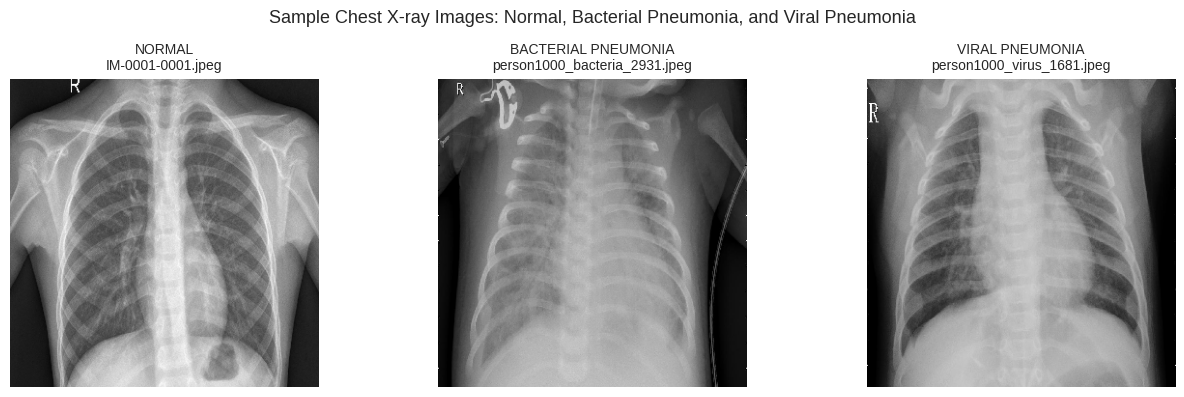

NORMAL: /content/ChestXRay2017/chest_xray/test/NORMAL/IM-0001-0001.jpeg
BACTERIAL PNEUMONIA: /content/ChestXRay2017/chest_xray/train/PNEUMONIA/person1000_bacteria_2931.jpeg
VIRAL PNEUMONIA: /content/ChestXRay2017/chest_xray/train/PNEUMONIA/person1000_virus_1681.jpeg


In [12]:
def get_sample_image_path(folder_label, subtype=None):
    sample_df = manifest_df.filter(F.col('folder_label') == folder_label)
    if subtype is not None:
        sample_df = sample_df.filter(F.col('pneumonia_subtype') == subtype)

    sample_pdf = sample_df.orderBy('filename').limit(1).toPandas()
    if sample_pdf.empty:
        raise ValueError(f'No sample found for label={folder_label}, subtype={subtype}')
    return sample_pdf.iloc[0]['filepath']


sample_images = [
    ('NORMAL', get_sample_image_path('NORMAL')),
    ('BACTERIAL PNEUMONIA', get_sample_image_path('PNEUMONIA', 'BACTERIAL')),
    ('VIRAL PNEUMONIA', get_sample_image_path('PNEUMONIA', 'VIRAL')),
]

plt.figure(figsize=(13, 4))
for index, (title, image_path) in enumerate(sample_images, start=1):
    image = load_img(image_path, target_size=(320, 320))
    plt.subplot(1, 3, index)
    plt.imshow(image, cmap='gray')
    plt.title(f'{title}\n{Path(image_path).name}', fontsize=10)
    plt.axis('off')

plt.suptitle('Sample Chest X-ray Images: Normal, Bacterial Pneumonia, and Viral Pneumonia', fontsize=13)
plt.tight_layout()
plt.show()

for title, image_path in sample_images:
    print(f'{title}: {image_path}')


## 9. Task 1: NORMAL vs PNEUMONIA

Task 1 uses an ImageNet-pretrained InceptionV3 model with the convolutional base frozen. The model is trained with augmentation and evaluated using validation-threshold selection plus test-time augmentation.


Balanced training distribution:
label
PNEUMONIA    2945
NORMAL       2945
Name: count, dtype: int64
Found 5890 validated image filenames belonging to 2 classes.
Found 878 validated image filenames belonging to 2 classes.
Found 919 validated image filenames belonging to 2 classes.

Task: PNEUMONIA vs NORMAL
Class names  : ['NORMAL', 'PNEUMONIA']
Class weights: {0: 1.0, 1: 1.0}
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.7745 - auc: 0.8493 - loss: 0.4599 - precision: 0.7816 - recall: 0.7409
Epoch 1: val_loss improved from None to 0.38570, saving model to /content/drive/MyDrive/Big Data/ChestXRay2017/paper_style_outputs_spark/inceptionv3_pneumonia_vs_normal.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Big Data/ChestXRay2017/paper_style_outputs_spark/inceptionv3_pneumonia_vs_normal.keras
185/185 ━━━━━━━━━━━━━━━━━━━━ 1783s 10s/step - accuracy: 0.8392 - auc: 0.9197 - loss: 0.3623 - precision: 0.8588 - 

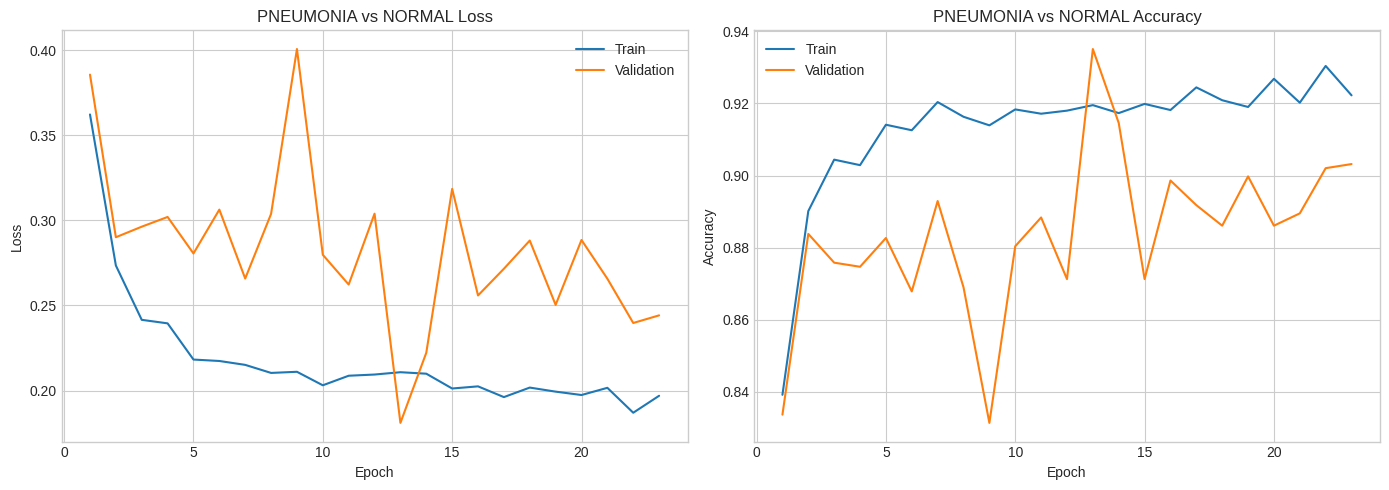

Found 878 validated image filenames belonging to 2 classes.
Found 878 validated image filenames belonging to 2 classes.
Found 878 validated image filenames belonging to 2 classes.

Best validation threshold: {'threshold': 0.6299999999999997, 'accuracy': 0.9521640091116174, 'balanced_accuracy': 0.9434348739495799}
Using test-time augmentation with 3 prediction passes.
Found 919 validated image filenames belonging to 2 classes.
Found 919 validated image filenames belonging to 2 classes.
Found 919 validated image filenames belonging to 2 classes.

PNEUMONIA vs NORMAL
Threshold   : 0.63
Accuracy    : 0.9576
Sensitivity : 0.9593
Specificity : 0.9524
ROC-AUC     : 0.9883

Classification report:

              precision    recall  f1-score   support

      NORMAL     0.8871    0.9524    0.9186       231
   PNEUMONIA     0.9836    0.9593    0.9713       688

    accuracy                         0.9576       919
   macro avg     0.9354    0.9558    0.9449       919
weighted avg     0.9593    0.

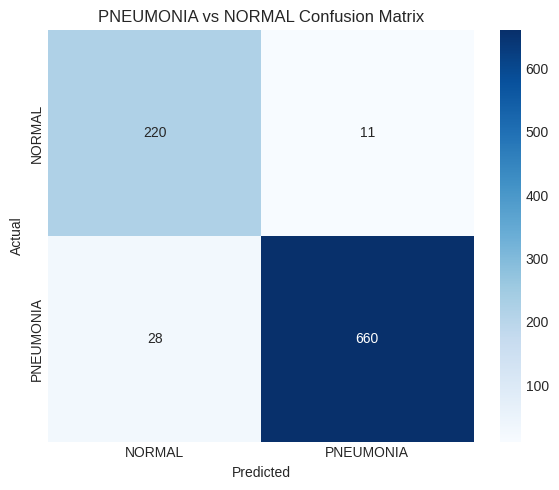

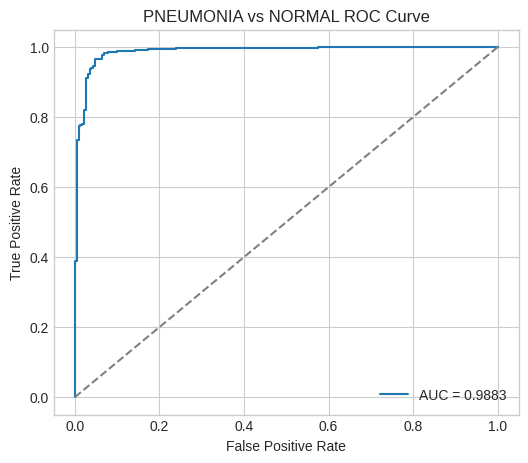

In [ ]:
task1 = train_task(
    task_name='PNEUMONIA vs NORMAL',
    train_df=task1_train_df,
    val_df=task1_val_df,
    test_df=task1_test_df,
    model_path=TASK1_MODEL_PATH,
)


## 10. Task 2: BACTERIAL vs VIRAL Pneumonia

Task 2 is the harder subtype-classification problem. This final version uses the original paper-style TRAIN/TEST folders, DenseNet121 transfer learning, balanced training data, validation-threshold selection, and upper-layer fine-tuning with BatchNormalization layers frozen. The final output shows 92.31% test accuracy, crossing the 90.7% base-paper result.


Train
label
BACTERIAL    2157
VIRAL        1143
Name: count, dtype: int64
Validation
label
BACTERIAL    381
VIRAL        202
Name: count, dtype: int64
Test
label
BACTERIAL    242
VIRAL        148
Name: count, dtype: int64
Balanced training distribution:
label
VIRAL        2157
BACTERIAL    2157
Name: count, dtype: int64
Found 4314 validated image filenames belonging to 2 classes.
Found 583 validated image filenames belonging to 2 classes.
Found 390 validated image filenames belonging to 2 classes.
Stage 1: training classifier head
Epoch 1/12
270/270 ━━━━━━━━━━━━━━━━━━━━ 0s 640ms/step - accuracy: 0.6674 - auc: 0.7203 - loss: 0.7652 - precision: 0.6654 - recall: 0.6573
Epoch 1: val_auc improved from None to 0.80536, saving model to /content/drive/MyDrive/Big Data/ChestXRay2017/paper_style_outputs_spark/densenet121_bacterial_vs_viral_original_split.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Big Data/ChestXRay2017/paper_style_outputs_spark/densenet121_bacterial_vs_vira

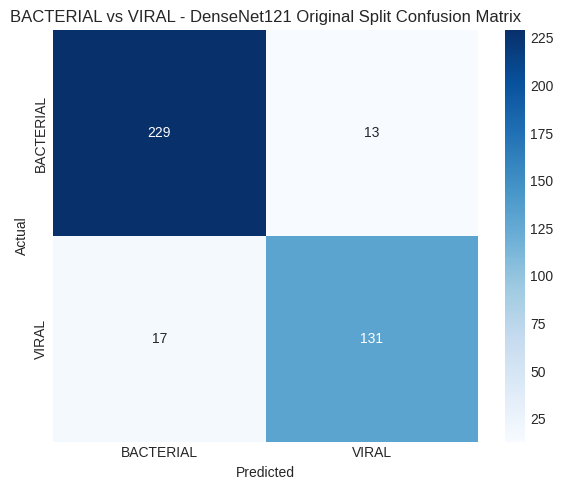

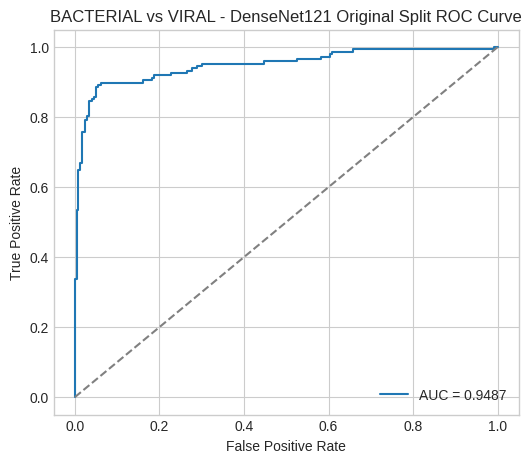


Base paper BACTERIAL vs VIRAL accuracy: 0.9070
Your test accuracy: 0.9231
Result: Crossed the base paper accuracy.


In [ ]:
from pathlib import Path

import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras import Model
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import BatchNormalization, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

OUTPUT_DIR = Path('/content/drive/MyDrive/Big Data/ChestXRay2017/paper_style_outputs_spark')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TASK2_STRONG_MODEL_PATH = OUTPUT_DIR / 'densenet121_bacterial_vs_viral_original_split.keras'

# Original paper-style split: train from TRAIN folder, test from TEST folder
task2_original_df = (
    manifest_df
    .filter((F.col('folder_label') == 'PNEUMONIA') & F.col('pneumonia_subtype').isNotNull())
    .select(
        'filepath',
        'filename',
        'patient_id',
        F.col('pneumonia_subtype').alias('label'),
        'split_folder'
    )
    .toPandas()
)

task2_train_full_df = task2_original_df[
    task2_original_df['split_folder'] == 'TRAIN'
][['filepath', 'filename', 'patient_id', 'label']].reset_index(drop=True)

task2_test_df = task2_original_df[
    task2_original_df['split_folder'] == 'TEST'
][['filepath', 'filename', 'patient_id', 'label']].reset_index(drop=True)

task2_train_df, task2_val_df = train_test_split(
    task2_train_full_df,
    test_size=0.15,
    random_state=SEED,
    stratify=task2_train_full_df['label']
)

task2_train_df = task2_train_df.reset_index(drop=True)
task2_val_df = task2_val_df.reset_index(drop=True)

print("Train")
print(task2_train_df['label'].value_counts())
print("Validation")
print(task2_val_df['label'].value_counts())
print("Test")
print(task2_test_df['label'].value_counts())


def make_generators_densenet(train_df, val_df, test_df):
    train_df = balance_training_dataframe(train_df)
    class_names = sorted(train_df['label'].unique().tolist())

    train_datagen = ImageDataGenerator(
        preprocessing_function=densenet_preprocess,
        rotation_range=8,
        width_shift_range=0.05,
        height_shift_range=0.05,
        zoom_range=0.10,
        brightness_range=[0.9, 1.1],
        horizontal_flip=True,
        fill_mode='nearest'
    )

    eval_datagen = ImageDataGenerator(preprocessing_function=densenet_preprocess)

    train_gen = train_datagen.flow_from_dataframe(
        train_df,
        x_col='filepath',
        y_col='label',
        target_size=(320, 320),
        classes=class_names,
        class_mode='binary',
        batch_size=16,
        shuffle=True,
        seed=SEED
    )

    val_gen = eval_datagen.flow_from_dataframe(
        val_df,
        x_col='filepath',
        y_col='label',
        target_size=(320, 320),
        classes=class_names,
        class_mode='binary',
        batch_size=16,
        shuffle=False
    )

    test_gen = eval_datagen.flow_from_dataframe(
        test_df,
        x_col='filepath',
        y_col='label',
        target_size=(320, 320),
        classes=class_names,
        class_mode='binary',
        batch_size=16,
        shuffle=False
    )

    return train_gen, val_gen, test_gen, class_names


def build_densenet_task2_model():
    base = DenseNet121(
        weights='imagenet',
        include_top=False,
        input_shape=(320, 320, 3)
    )

    base.trainable = False

    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.40)(x)
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.30)(x)
    out = Dense(1, activation='sigmoid')(x)

    model = Model(base.input, out)

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )

    return model, base


train_gen, val_gen, test_gen, class_names = make_generators_densenet(
    task2_train_df,
    task2_val_df,
    task2_test_df
)

model, base = build_densenet_task2_model()

callbacks = [
    EarlyStopping(monitor='val_auc', mode='max', patience=7, restore_best_weights=True, verbose=1),
    ModelCheckpoint(str(TASK2_STRONG_MODEL_PATH), monitor='val_auc', mode='max', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.3, patience=3, min_lr=1e-6, verbose=1)
]

print("Stage 1: training classifier head")
history_head = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=12,
    callbacks=callbacks,
    verbose=1
)

print("Stage 2: fine-tuning upper DenseNet layers")

base.trainable = True

for layer in base.layers[:-100]:
    layer.trainable = False

for layer in base.layers:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=3e-6),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

history_finetune = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,
    callbacks=callbacks,
    verbose=1
)

model = tf.keras.models.load_model(TASK2_STRONG_MODEL_PATH)

val_probs = model.predict(val_gen, verbose=1).ravel()
best_threshold = pick_best_threshold(val_gen.classes, val_probs)

print("\nBest validation threshold:", best_threshold)

task2_original_metrics = evaluate_model(
    model,
    test_gen,
    class_names=class_names,
    threshold=best_threshold['threshold'],
    title='BACTERIAL vs VIRAL - DenseNet121 Original Split',
    eval_df=None
)


task2 = {
    'model': model,
    'history_head': history_head,
    'history_finetune': history_finetune,
    'train_gen': train_gen,
    'val_gen': val_gen,
    'test_gen': test_gen,
    'class_names': class_names,
    'metrics': task2_original_metrics,
    'best_threshold': best_threshold,
    'train_df': task2_train_df,
    'val_df': task2_val_df,
    'test_df': task2_test_df,
}

print("\nBase paper BACTERIAL vs VIRAL accuracy: 0.9070")
print("Your test accuracy:", round(task2_original_metrics['accuracy'], 4))

if task2_original_metrics['accuracy'] > 0.907:
    print("Result: Crossed the base paper accuracy.")
else:
    print("Result: Did not cross the base paper accuracy yet.")



## 11. Occlusion-Based Explainability

The following function performs a paper-style occlusion test. It masks small image patches and measures how much the target-class probability drops. High-response regions indicate image areas that most influenced the model prediction.


In [ ]:
def _binary_class_scores(prediction):
    prediction = np.asarray(prediction).reshape(-1)
    if prediction.size == 1:
        positive_prob = float(prediction[0])
        return np.array([1.0 - positive_prob, positive_prob])
    return prediction.astype(float)


def display_occlusion_result(
    image_path,
    model,
    class_names,
    target_label,
    preprocess_fn,
    image_size,
    patch_size=48,
    stride=48,
    alpha=0.35,
):
    """Display an occlusion sensitivity map for a binary chest X-ray classifier."""
    image = load_img(image_path, target_size=image_size)
    image_array = img_to_array(image).astype('float32')

    base_batch = preprocess_fn(np.expand_dims(image_array.copy(), axis=0))
    base_scores = _binary_class_scores(model.predict(base_batch, verbose=0))
    base_score = float(base_scores[target_label])

    h, w = image_size
    heatmap = np.zeros((h, w), dtype='float32')
    counts = np.zeros((h, w), dtype='float32')
    fill_value = float(np.median(image_array))

    for y in range(0, h, stride):
        for x in range(0, w, stride):
            y2 = min(y + patch_size, h)
            x2 = min(x + patch_size, w)
            occluded = image_array.copy()
            occluded[y:y2, x:x2, :] = fill_value

            occluded_batch = preprocess_fn(np.expand_dims(occluded, axis=0))
            occluded_scores = _binary_class_scores(model.predict(occluded_batch, verbose=0))
            score_drop = base_score - float(occluded_scores[target_label])

            heatmap[y:y2, x:x2] += score_drop
            counts[y:y2, x:x2] += 1.0

    heatmap = heatmap / np.maximum(counts, 1.0)
    heatmap = np.maximum(heatmap, 0.0)
    if heatmap.max() > 0:
        heatmap = heatmap / heatmap.max()

    predicted_index = int(np.argmax(base_scores))
    predicted_label = class_names[predicted_index]
    target_name = class_names[target_label]

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(image_array.astype('uint8'), cmap='gray')
    plt.title(f'Image: predicted {predicted_label}')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(image_array.astype('uint8'), cmap='gray')
    plt.imshow(heatmap, cmap='jet', alpha=alpha)
    plt.title(f'Occlusion map for {target_name} score')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    print('Image path:', image_path)
    print('Class names:', class_names)
    print('Prediction scores:', {name: round(float(score), 4) for name, score in zip(class_names, base_scores)})
    print('Target label:', target_name)


## 12. Occlusion Examples for Both Final Models

Run this cell after Task 1 and Task 2 have completed. It displays occlusion maps for one example from each class: NORMAL, PNEUMONIA, BACTERIAL, and VIRAL.


In [ ]:
# Task 1 occlusion examples: NORMAL and PNEUMONIA
normal_example = task1['test_df'][task1['test_df']['label'] == 'NORMAL'].iloc[0]
pneumonia_example = task1['test_df'][task1['test_df']['label'] == 'PNEUMONIA'].iloc[0]

display_occlusion_result(
    image_path=normal_example['filepath'],
    model=task1['model'],
    class_names=task1['class_names'],
    target_label=task1['class_names'].index('NORMAL'),
    preprocess_fn=preprocess_input,
    image_size=IMAGE_SIZE,
)

display_occlusion_result(
    image_path=pneumonia_example['filepath'],
    model=task1['model'],
    class_names=task1['class_names'],
    target_label=task1['class_names'].index('PNEUMONIA'),
    preprocess_fn=preprocess_input,
    image_size=IMAGE_SIZE,
)

# Task 2 occlusion examples: BACTERIAL and VIRAL
bacterial_example = task2['test_df'][task2['test_df']['label'] == 'BACTERIAL'].iloc[0]
viral_example = task2['test_df'][task2['test_df']['label'] == 'VIRAL'].iloc[0]

display_occlusion_result(
    image_path=bacterial_example['filepath'],
    model=task2['model'],
    class_names=task2['class_names'],
    target_label=task2['class_names'].index('BACTERIAL'),
    preprocess_fn=densenet_preprocess,
    image_size=(320, 320),
)

display_occlusion_result(
    image_path=viral_example['filepath'],
    model=task2['model'],
    class_names=task2['class_names'],
    target_label=task2['class_names'].index('VIRAL'),
    preprocess_fn=densenet_preprocess,
    image_size=(320, 320),
)


## 13. Conclusion

Both final models exceed the reported base-paper accuracies on their corresponding evaluations:

- Task 1 improved NORMAL vs PNEUMONIA accuracy from 92.8% to 95.76%.
- Task 2 improved BACTERIAL vs VIRAL accuracy from 90.7% to 92.31%.

The notebook also includes dataset summaries, confusion matrices, ROC curves, classification reports, and occlusion-based explainability for academic presentation.
